## Clasificación Múltiple con el Dataset MINST

### Cargar el Dataset de MINST

IMportemos el mdoulo de MINST desde keras

In [19]:
from tensorflow.keras.datasets import mnist

Carguemos los datos a nuestras tuplas clásicas de Train y test

In [20]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

### Exploración de Datos

Obten el Shape de XTrain

In [21]:
X_train.shape

(60000, 28, 28)

Obten el Shape de yTrain

In [22]:
y_train.shape

(60000,)

Obten el Shape de XTest

In [23]:
X_test.shape

(10000, 28, 28)

Obten el Shape de yTrain

In [24]:
y_train.shape

(60000,)

Activa Matplotlib inline

In [25]:
%matplotlib inline

Importa matplotlib como plt

In [26]:
import matplotlib.pyplot as plt

Importa Seaborn

In [27]:
import seaborn as sns

Pon su escala a 2

In [28]:
sns.set(font_scale=2)

Importa Numpy

In [29]:
import numpy as np

Ahora armate un programa que muestre 24 digitos

In [30]:
indice = np.random.choice(np.arange(len(X_train)),24,replace=False)

In [31]:
indice

array([ 9108,  7992, 34426, 53867,  4609, 58545, 43178, 16011, 31029,
       24530,  1476, 28285, 42756, 37701, 35817, 11105,  5823, 31810,
         787, 58535, 11311, 57414, 58167, 23807])

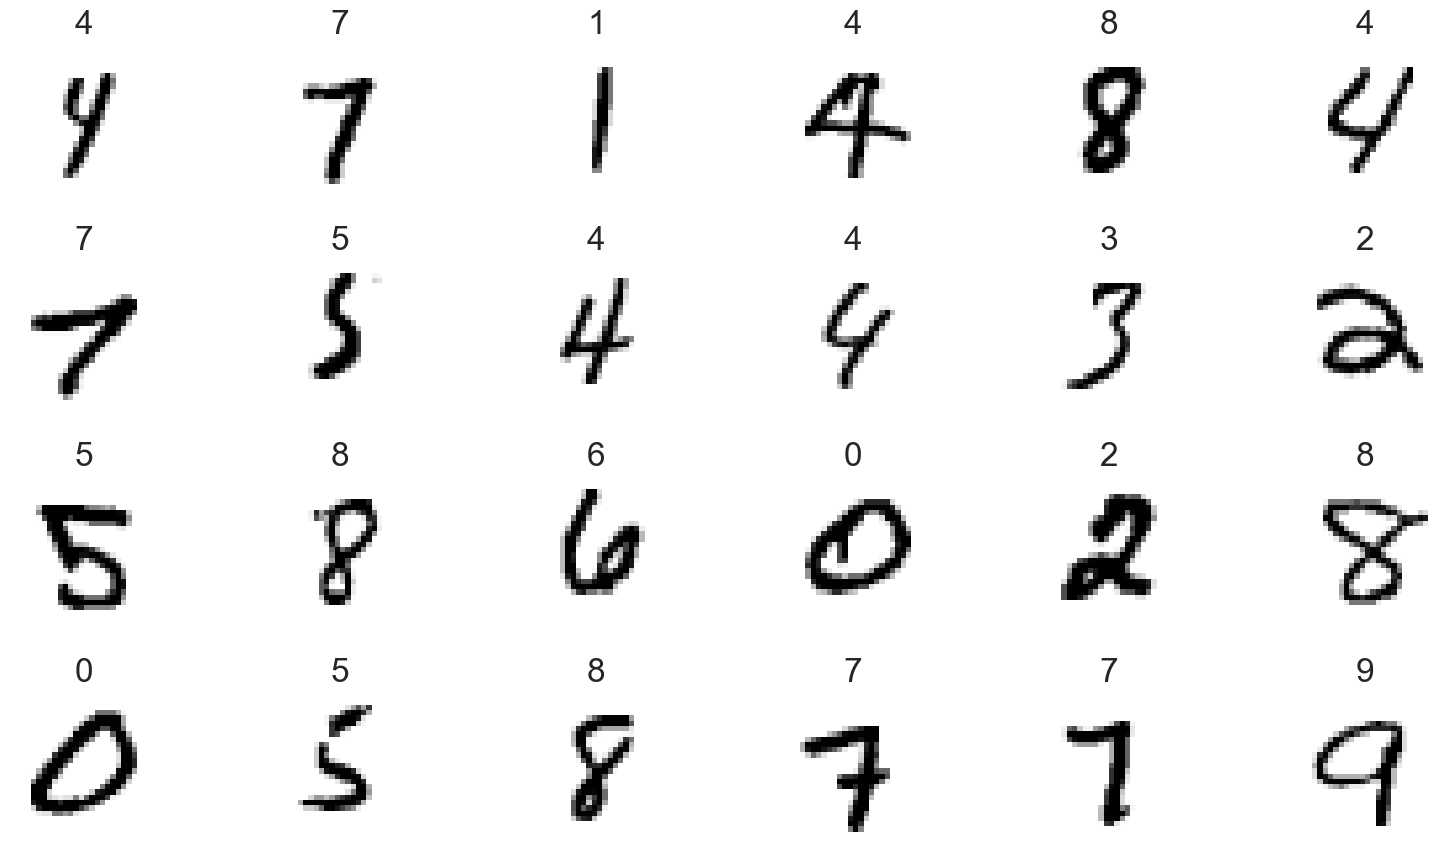

In [32]:
figure,axes = plt.subplots(nrows=4, ncols=6, figsize=(16,9))
for item in zip(axes.ravel(),X_train[indice], y_train[indice]):
    axes, image, target = item
    axes.imshow(image,cmap=plt.cm.gray_r)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_title(target)
plt.tight_layout()
plt.show()

### Preparar los datos

Cambia la figura de Xtrain a 60000 x 28 x 28 x 1

In [33]:
X_train = X_train.reshape((60000,28,28,1))

Checa su shape

In [34]:
X_train.shape

(60000, 28, 28, 1)

In [35]:
X_test = X_test.reshape((10000,28,28,1))

Checa su Shape

In [36]:
X_test.shape

(10000, 28, 28, 1)

Normaliza con astype Xtrain

In [37]:
X_train = X_train.astype("float32")/255

Normaliza con astype Xtest

In [38]:
X_test = X_test.astype("float32")/255

Desde tensorflow importa to_categorical

In [39]:
from tensorflow.keras.utils import to_categorical

aplicalo a Y_train

In [40]:
y_train = to_categorical(y_train)

Checa su shape

In [41]:
y_train.shape

(60000, 10)

Checa el primer dato de Y_train

In [42]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

Aplica to_categorical a Y-test

In [43]:
y_test = to_categorical(y_test)

Checa su figura

In [44]:
y_test.shape

(10000, 10)

### Crear la Red Neuronal

Importa Sequential desde tf

In [45]:
from tensorflow.keras.models import Sequential

Crea tu objeto cnn

In [46]:
cnn = Sequential()

importa las capas que necesitaras desde tf

In [47]:
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, Input

agrega la capa de Conv2d

In [48]:
cnn.add(Conv2D(filters=64, kernel_size=(3,3),activation ="relu", input_shape=(28,28,1)))

C:\Users\Almicar\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Ahora agrega una capa de Pooling2d

In [49]:
cnn.add(MaxPooling2D(pool_size=(2,2)))

Agrega otra caba de Conv2D

In [50]:
cnn.add(Conv2D(filters=128, kernel_size=(3,3), activation="relu"))

Y otra de Pooling

In [51]:
cnn.add(MaxPooling2D(pool_size=(2,2)))

Aplana los resultados

In [52]:
cnn.add(Flatten())

Agrega una capa DENSE

In [53]:
cnn.add(Dense(units=128,activation="relu"))

Y otra DENSE

In [54]:
cnn.add(Dense(units=10,activation="softmax"))

Imprime el resultado en un resumen

In [55]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Visualiza la estructura del modelo

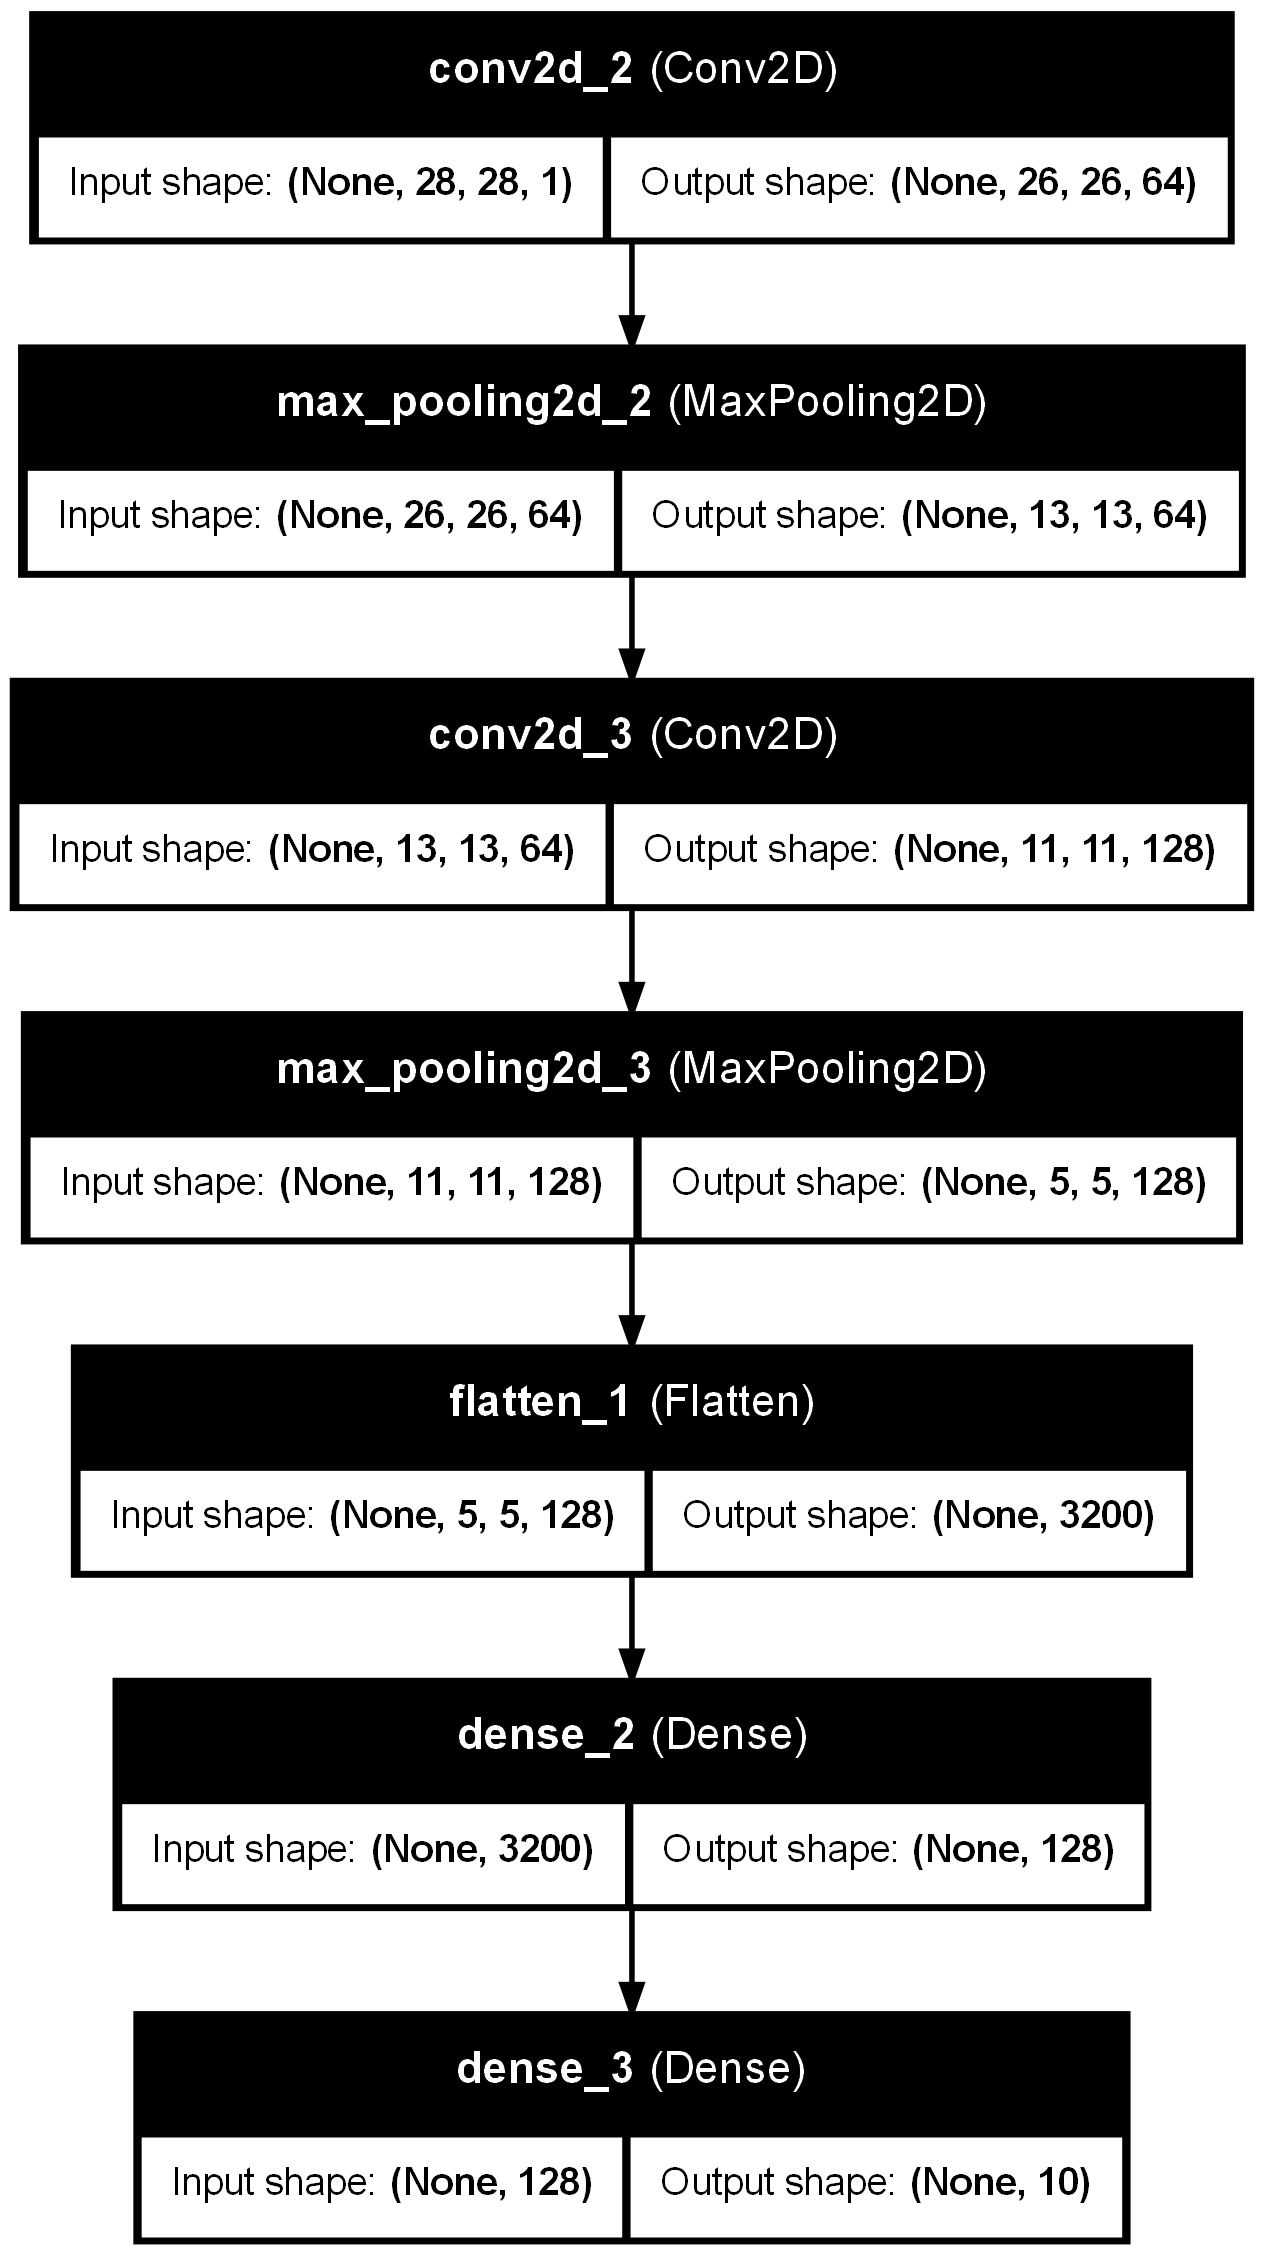

In [57]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image

plot_model(cnn, to_file="covnet.png",show_shapes=True, show_layer_names=True)

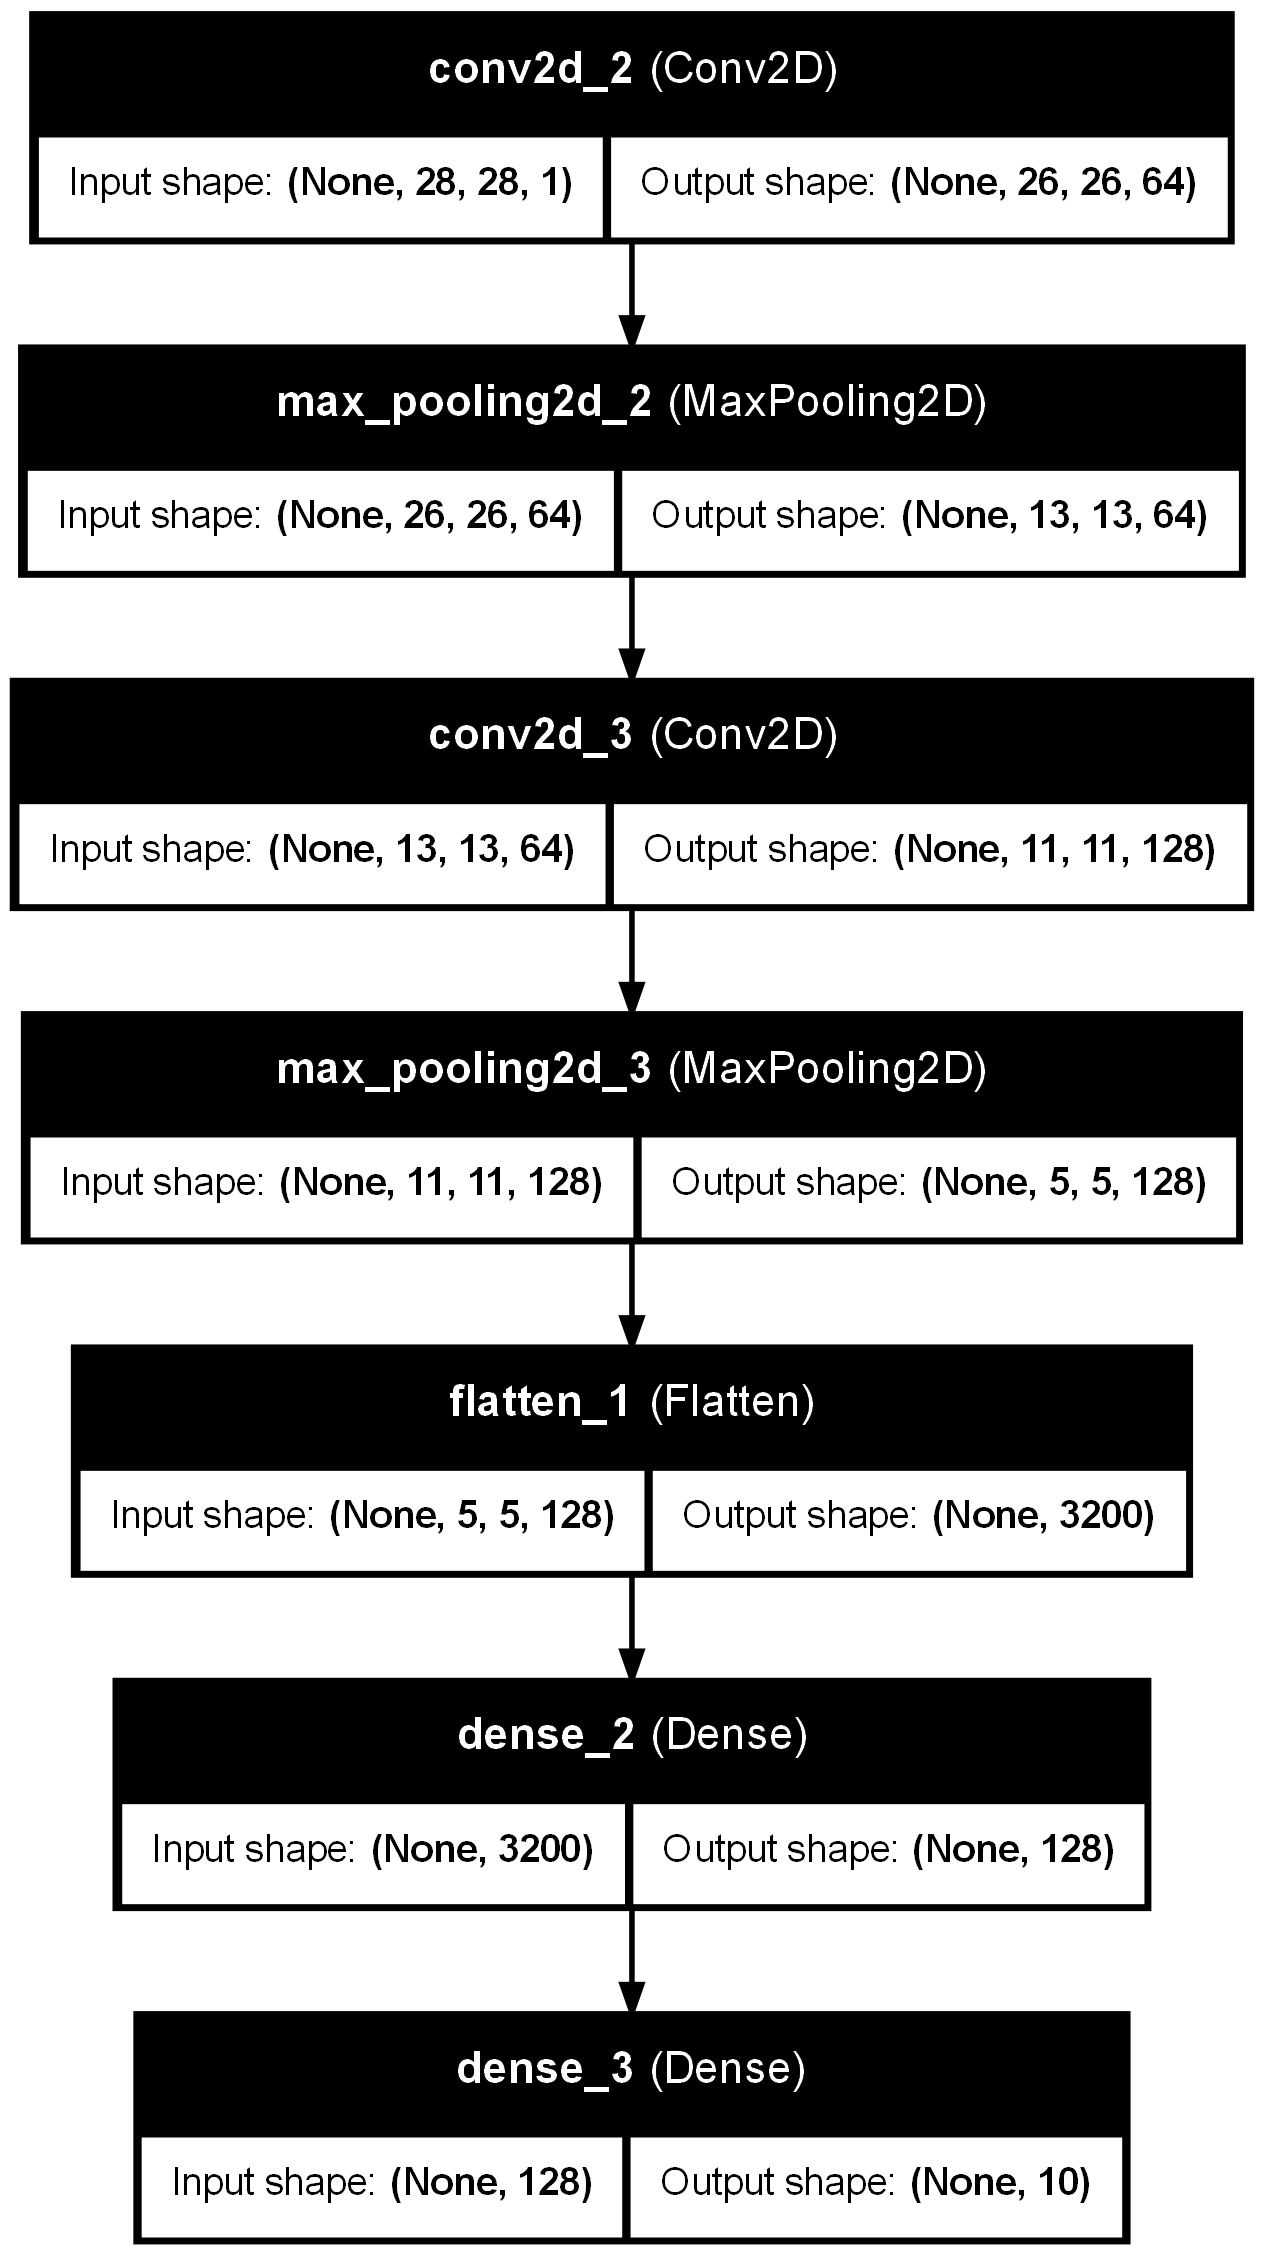

In [58]:
Image(filename="covnet.png")

Compila tu modelo

In [61]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"])

### Entrenar y Evaluar el modelo

Entrena tu modelo con fit

In [62]:
cnn.fit(X_train,y_train,epochs=5,batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9585 - loss: 0.1346 - val_accuracy: 0.9870 - val_loss: 0.0497
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9868 - loss: 0.0419 - val_accuracy: 0.9902 - val_loss: 0.0401
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9907 - loss: 0.0288 - val_accuracy: 0.9893 - val_loss: 0.0342
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9934 - loss: 0.0204 - val_accuracy: 0.9900 - val_loss: 0.0383
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9951 - loss: 0.0145 - val_accuracy: 0.9900 - val_loss: 0.0346


Evalua le modelo con Evaluate

In [63]:
loss,accuracy=cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9901 - loss: 0.0304


In [64]:
loss

0.030370431020855904

In [65]:
accuracy

0.9901000261306763

Vamos a hacer predicciones

In [66]:
predicciones = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


checa que dice el primer elemento de ytest

In [67]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

Y ahora que dice el primer elemento del modelo

In [69]:
for index, probability in enumerate(predicciones[0]):
    print(f'{index}: {probability:.10%}')

0: 0.0000000005%
1: 0.0000000039%
2: 0.0000001577%
3: 0.0000000698%
4: 0.0000000000%
5: 0.0000000005%
6: 0.0000000000%
7: 100.0000000000%
8: 0.0000002432%
9: 0.0000000487%


Ubiquemos las predicciones incorreectas

In [70]:
images =X_test.reshape((10000,28,28))
incorrect_predictions=[]

In [71]:
for i,(p,e) in enumerate(zip(predicciones,y_test)):
    predicted, expected = np.argmax(p), np.argmax(e)

    if predicted != expected:
        incorrect_predictions.append((i,images[i],predicted, expected))

Obten el largo de esa lista

In [73]:
len(incorrect_predictions)

99

Visualiza las predicciones incorrectas

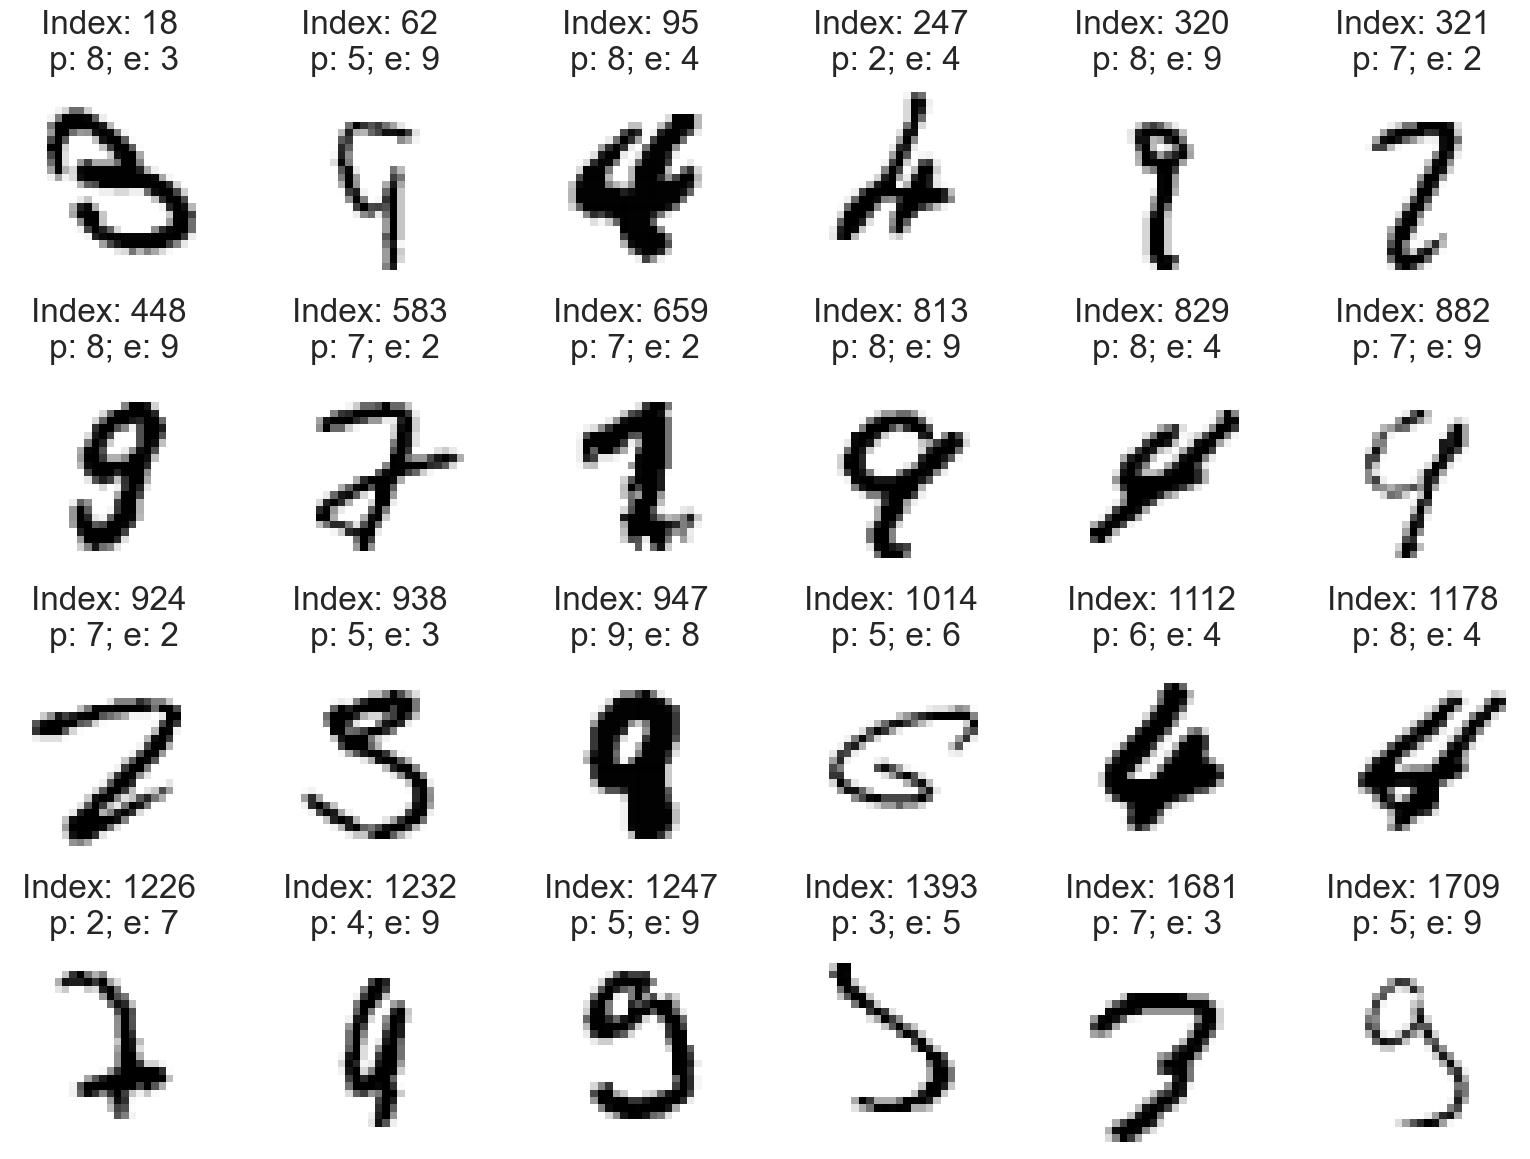

In [78]:
figure, axes = plt.subplots(nrows= 4, ncols =6,figsize=(16,12))

for axes, item in zip(axes.ravel(), incorrect_predictions):
    index, image, predicted, expected = item
    axes.imshow(image,cmap=plt.cm.gray_r)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_title(f'Index: {index} \np: {predicted}; e: {expected}')
plt.tight_layout()
plt.show()

Arma una funcion que genere un listado de las probabilidades para predicciones incorrectas

In [89]:
def muestraprob(prediction):
    for index, probability, in enumerate(prediction):
        print(f'{index}: {probability:.10%}')

Muestra una que otra predicción incorrecta a detalles

In [92]:
muestraprob(predicciones[582])

0: 0.0000098078%
1: 0.0012346249%
2: 13.1880536675%
3: 0.0661923201%
4: 0.0000007358%
5: 0.0000013912%
6: 0.0000636479%
7: 0.0000310854%
8: 86.7444097996%
9: 0.0000000039%


### Guardar tu Modelo

In [93]:
cnn.save("mnist_cnn.h5")

In [94]:
from tensorflow.keras.models import load_model

In [98]:
dan = load_model("mnist_cnn.h5")

## Analisis de Sentimientos con Redes Neuronales - IMDB

### Cargar el dataset de IMBD

Import el dataset de imdb desde tensorlfow.keras.datasets

In [99]:
from tensorflow.keras.datasets import imdb

Carga las 10000 palabras que mas ocurren

In [102]:
numeropalabras = 80000

Carga tus palabras en tus datasets X_train y X_test y asi

In [104]:
(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words = numeropalabras)

### Exploracion de Datos

Figura de X_train

In [105]:
X_train.shape

(25000,)

Figura de Y_train

In [106]:
y_train.shape

(25000,)

Figura de X_test

In [107]:
X_test.shape

(25000,)

Figura de y_test

In [108]:
y_test.shape

(25000,)

Apaga pretty print

In [109]:
%pprint

Pretty printing has been turned OFF


Checa un elemento cualquiera de X_train

In [110]:
X_train[150]

[1, 5, 14, 9, 6, 55, 1193, 22, 13, 203, 30, 355, 21, 14, 9, 4, 236, 22, 121, 13, 1192, 2967, 3622, 35, 779, 284, 37, 5844, 4, 217, 5, 2132, 6, 749, 10, 10, 2636, 4252, 5, 2931, 4517, 26, 82, 321, 36, 26, 19308, 5, 4960, 15152, 1786, 8, 358, 4, 704, 117, 122, 36, 124, 51, 62, 593, 375, 10, 10, 4, 1381, 5, 732, 26, 821, 5, 1249, 14, 16, 159, 4, 504, 7, 3728, 4913, 10, 10, 51, 9, 91, 1193, 44, 14, 22, 9, 4, 192, 15, 1370, 40, 14, 131, 1778, 11, 938, 704, 3834, 131, 25645, 543, 84, 12, 9, 220, 6, 1117, 5, 6, 320, 237, 4, 3286, 325, 10, 10, 25, 80, 358, 14, 22, 12, 16, 814, 11, 4, 3968, 8084, 7, 1226, 7111, 63, 131, 1778, 43, 92, 1278, 501, 15, 8, 6353, 19881, 15, 1609, 131, 47, 24, 77, 31131, 237, 12648, 30905, 158, 158]

Llama la función word to index

In [111]:
word_to_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Checa el indice de la palabra "bad"

In [112]:
word_to_index["bad"]

75

Reversa el mapeo del diccionario Word to INdex a Index to Word

In [113]:
index_to_word = {index:word for(word,index) in word_to_index.items()}

In [114]:
index_to_word[75]

'bad'

Armate una lista para revisar las 50 palabras mas comunes en el diccionario

In [115]:
[index_to_word[i] for i in range(1,51)]

['the', 'and', 'a', 'of', 'to', 'is', 'br', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not', 'you', 'are', 'his', 'have', 'he', 'be', 'one', 'all', 'at', 'by', 'an', 'they', 'who', 'so', 'from', 'like', 'her', 'or', 'just', 'about', "it's", 'out', 'has', 'if', 'some', 'there', 'what', 'good', 'more']

Ok, ya estamos listos para leer una reseña

In [116]:
" ".join([index_to_word.get(i-3,"?") for i in X_train[123]])

'? beautiful and touching movie rich colors great settings good acting and one of the most charming movies i have seen in a while i never saw such an interesting setting when i was in china my wife liked it so much she asked me to log on and rate it so other would enjoy too'

Y revisa de Y_train la clasificacion de esta reseña

In [117]:
y_train[123]

np.int64(1)

### Preparación de datos

Define palabras_por_reseña en 200

In [118]:
numpa1 = 200

Importa pad_sequences de tensroflow

In [119]:
from tensorflow.keras.preprocessing.sequence

SyntaxError: invalid syntax (1531916601.py, line 1)

Define X_train como pad_sequences del viejo X_train

Checa el nuevo shape de X_train

Hay que reconfigurar X_Test tambien

Checa su figura

Importa el Train_test_split y definelo sobre tus variables, semilla 11 y tamaño de prueba de .20

Checa la figura de xtest

Y la de XVal

### Crear la red neuronal

Desde Tensorflow importa Sequencial

arma el objeto rnn com oun sequential

Importa las capas Dense y LSTM

Importa Embedding

Agrega la capa de Embedding, que salgan 128 dimensiones

agrega la capa de LSTM

Agrega una capa DENSE

Compila el RNN

Y resvisa el resultado de RNN

### Entrenar y evaluar el modelo

Usa Fit para entrenar el mdoelo

Checa tus resultados

Y revisa el resultado